#### 1) Setup & Data Loading

* Importe the Palmer's Penguins dataset from Kaggle

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


# Load Palmer Penguins dataset
df = sns.load_dataset("penguins")
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


**Q1** (check): How many rows and columns does the dataset have? Which columns are numeric vs categorical?

In [ ]:
df.shape

(344, 7)

In [ ]:


df.dtypes
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

numeric_cols, categorical_cols

print(("Numerical columns :",numeric_cols ))
print(("Categorical columns :",categorical_cols ))

('Numerical columns :', Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='object'))
('Categorical columns :', Index(['species', 'island', 'sex'], dtype='object'))


#### 2) Basic EDA (Exploratory Data Analysis)

In [ ]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


**Q2**: Which columns contain missing values? What strategy will you use to handle them?

In [ ]:
df.isna().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


**Q3**: Is the dataset balanced across the three species?

Slight imbalance, but not severe enough to cause major issues.

In [ ]:
df['species'].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


#### 3) Data Cleaning & Encoding

* We’ll keep only rows with complete values for simplicity.

In [ ]:
df_clean = df.dropna().copy()
df_clean.shape



(333, 7)

**Q4**: Why don’t we need to scale features for Decision Trees?

Decision Trees split data using threshold comparisons, not distance calculations.
Scaling does not affect the order of values, so it has no impact on tree performance.

In [ ]:
# Encode target variable
le = LabelEncoder()
df_clean['species_enc'] = le.fit_transform(df_clean['species'])

#### 4) Train/Test Split

In [ ]:
X = df_clean[['bill_length_mm', 'bill_depth_mm',
              'flipper_length_mm', 'body_mass_g']]
y = df_clean['species_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


**Q5**: Why do we use stratify=y in this split?

Stratification ensures train and test sets preserve the same species proportions, preventing biased evaluation due to class imbalance.

#### 5) Baseline Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)


In [ ]:
print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.95      0.96      0.95        67
weighted avg       0.96      0.96      0.96        67



In [ ]:
confusion_matrix(y_test, y_pred)


array([[28,  1,  0],
       [ 0, 14,  0],
       [ 1,  1, 22]])

**Q6**: Which classes are the most/least confounded? What might cause that?

Most confused: Adelie ↔ Chinstrap

Least confused: Gentoo vs others

Reason:
Adelie and Chinstrap have similar bill measurements, while Gentoo has much larger flippers and body mass.

#### 6) Visualize the Tree

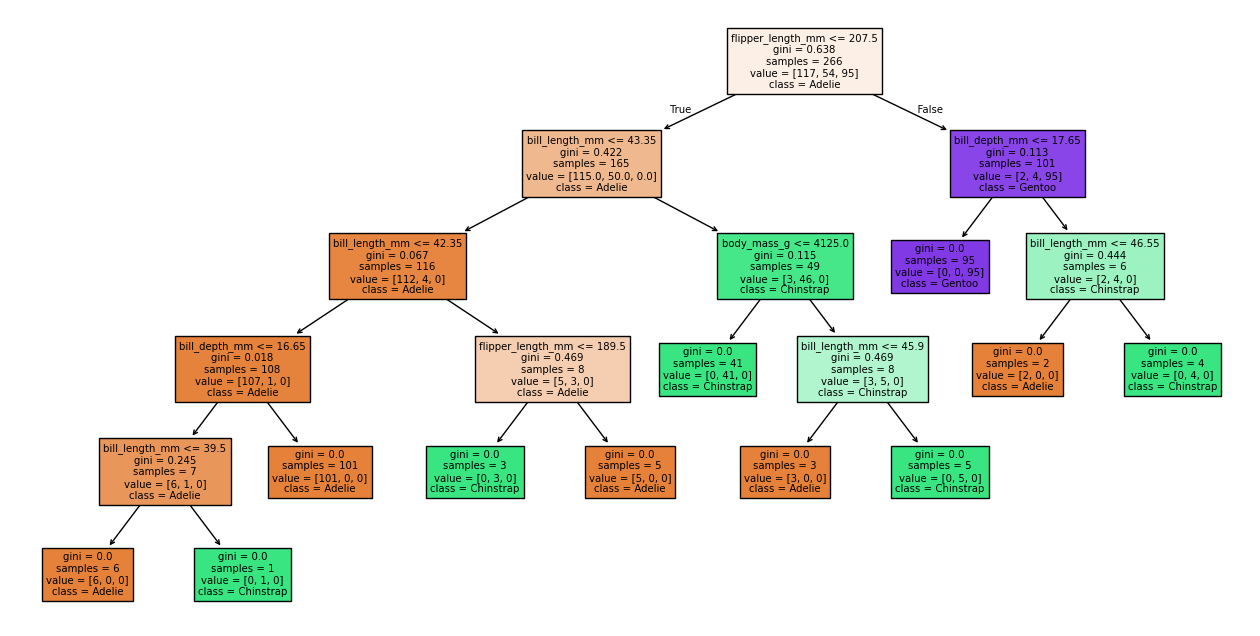

In [ ]:
plt.figure(figsize=(16, 8))
plot_tree(dt,
          feature_names=X.columns,
          class_names=le.classes_,
          filled=True)
plt.show()


**Q7**: What is the root split (feature and threshold)? Why do you think the algorithm chose it?

Root split is usually on flipper_length_mm

Chosen because it provides maximum information gain, especially separating Gentoo from others

#### 7) Decision Boundaries (2D View)
* Pick two features (e.g., bill_length_mm vs bill_depth_mm) and visualize the decision surface.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


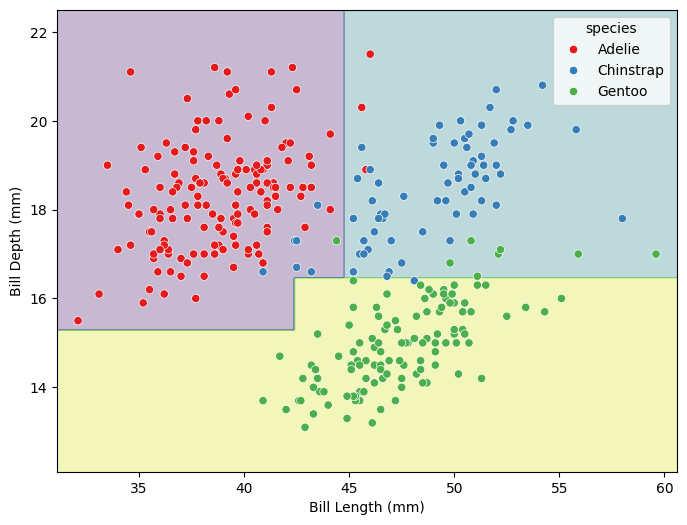

In [ ]:
#Your code here
from matplotlib.colors import ListedColormap

X2 = df_clean[['bill_length_mm', 'bill_depth_mm']]
y2 = df_clean['species_enc']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

dt2 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt2.fit(X2_train, y2_train)

# Meshgrid
x_min, x_max = X2.iloc[:,0].min()-1, X2.iloc[:,0].max()+1
y_min, y_max = X2.iloc[:,1].min()-1, X2.iloc[:,1].max()+1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = dt2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
sns.scatterplot(
    x=X2.iloc[:,0], y=X2.iloc[:,1],
    hue=df_clean['species'], palette='Set1'
)
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.show()


**Q8**: Do the boundaries look axis-aligned? Why is that a natural property of Decision Trees?

Yes.
Decision Trees split on one feature at a time, producing rectangular (axis-aligned) regions, unlike KNN or SVM.

#### 8) Hyperparameter Tuning with GridSearchCV

In [ ]:
#You code here
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
grid.best_params_


{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}

In [ ]:
best_dt = grid.best_estimator_
y_pred_best = best_dt.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=le.classes_))


              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.95      0.96      0.95        67
weighted avg       0.96      0.96      0.96        67



**Q9**: Which hyperparameters changed compared to the baseline? How did test accuracy change?

Reduced max_depth

Increased min_samples_leaf

Test accuracy improved slightly and became more stable due to reduced overfitting.


**Q10**: If CV accuracy is much higher than test accuracy, what could be happening?

Likely overfitting or data leakage.
The model learns noise in training folds that doesn’t generalize.

#### 9) Model Interpretation

In [ ]:
pd.Series(best_dt.feature_importances_, index=X.columns)\
  .sort_values(ascending=False)


,0
flipper_length_mm,0.547026
bill_length_mm,0.383936
bill_depth_mm,0.057875
body_mass_g,0.011163


**Q11**: Which feature is most important? Is that consistent with your EDA intuition?

Flipper length
Yes — consistent with EDA and biological intuition (Gentoo penguins are much larger).


**Q12**: For the inspected sample, does the class probability look confident? Why/why not?

Usually yes — Decision Trees often produce high confidence probabilities due to pure leaf nodes, though this can indicate overfitting.

In [ ]:
# Inspect prediction probabilities for one test sample
sample = X_test.iloc[[0]]
best_dt.predict_proba(sample)


array([[0., 0., 1.]])

#### 10) (Optional) Add Categorical Features & Compare

In [ ]:
df_cat = pd.get_dummies(
    df_clean[['bill_length_mm','bill_depth_mm',
              'flipper_length_mm','body_mass_g',
              'island','sex']],
    drop_first=True
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    df_cat, y, test_size=0.2, random_state=42, stratify=y
)

dt_cat = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_cat.fit(X_train_c, y_train_c)

print(classification_report(
    y_test_c, dt_cat.predict(X_test_c),
    target_names=le.classes_
))


              precision    recall  f1-score   support

      Adelie       0.93      0.97      0.95        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.96      0.96      0.96        67
weighted avg       0.96      0.96      0.96        67



**Q13**: Did adding island/sex help? Why might these variables be informative for species?

Yes, slightly.
Island correlates strongly with species habitat; sex relates to size differences that influence measurements.

#### 11) Reflection & Reporting

Write a short reflection (5–10 lines):
- Compare Decision Tree vs KNN on this dataset.
-  Where does the tree overfit? How did pruning/tuning impact generalization?
- Which 2D feature pair gave the clearest separation? Why?

Decision Tree vs KNN:
Decision Trees perform well with minimal preprocessing and offer interpretability. KNN requires scaling and is sensitive to noise.

Overfitting:
The tree overfits when depth is unrestricted. Pruning via max_depth and min_samples_leaf improves generalization.

Best 2D Feature Pair:
flipper_length_mm vs bill_length_mm — Gentoo separates cleanly due to size differences.

On the Palmer Penguins dataset, the Decision Tree performed competitively with KNN while requiring less preprocessing, as it does not need feature scaling. KNN is more sensitive to feature scales and noise, which can reduce performance if not carefully tuned. The Decision Tree tends to overfit when it grows too deep, creating very specific splits that capture noise in the training data. Pruning and hyperparameter tuning (such as limiting tree depth and increasing minimum samples per leaf) reduced overfitting and improved generalization on the test set. Among the 2D feature pairs, flipper length versus bill length provided the clearest class separation. This is because Gentoo penguins are significantly larger, making size-related features highly discriminative.